In [ ]:
import io, nltk, os, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from symspellpy import SymSpell, Verbosity
from langdetect import detect, LangDetectException
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [8]:
# 1. Persiapan Stemmer (Sastrawi)
nltk.download('stopwords', quiet=True)
factory = StemmerFactory()
stemmer = factory.create_stemmer()
print("Stemmer Sastrawi siap.")

# 2. Persiapan Stopwords (NLTK)
list_stopwords = stopwords.words('indonesian')

kata_penting = {'tidak', 'kurang', 'jangan', 'bukan', 'tapi', 'sangat', 'jauh'}
list_stopwords = [stopword for stopword in list_stopwords if stopword not in kata_penting]

# Stopword kustom (noise words)
list_stopwords.extend([
    'aja', 'amp', 'biar', 'bikin', 'bilang', 'broo', 'coyy', 'cuy', 'd',
    'deh', 'dg', 'dgn', 'dri', 'eh', 'euy', 'gaes', 'ges', 'guys', 'hehe',
    'hehehe', 'hai', 'halo', 'jgn', 'karna', 'ke', 'kok', 'mah', 'n', 'nah',
    'nih', 'nya', 'pas', 'sdh', 'sih', 't', 'tau', 'tuh', 'utk', 'wkwk',
    'wkwkwk', 'ya', 'yah', 'yee', 'yuhuuuu'
])

set_stopwords = set(list_stopwords)
print(f"Stopwords (dengan {len(set_stopwords)} kata, 'jauh' diamankan) siap.")

# 3. Kamus Slang (untuk Normalisasi)
kamus_slang = {
    'ad': 'ada', 'adem': 'dingin', 'ae': 'saja', 'aga': 'agak', 'agk': 'agak',
    'airasin': 'air asin', 'aja': 'saja', 'ajalahhh': 'saja lah', 'ajasi': 'saja sih',
    'ama': 'sama', 'anj': 'anjing', 'apalgi': 'apalagi', 'apesiiiigilak': 'apa sih gila',
    'apik': 'bagus', 'ato': 'atau', 'b': 'biasa', 'b aja': 'biasa saja',
    'bab': 'buang air besar', 'bak': 'buang air kecil', 'bangettt': 'banget',
    'bangett': 'banget', 'bangeeet': 'banget', 'bangetttt': 'banget', 'bangus': 'bagus',
    'banyka': 'banyak', 'basah2': 'basah-basah', "be'e": 'buang air besar', 'begtu': 'begitu',
    'belom': 'belum', 'bener': 'benar', 'beneran': 'benaran', 'ber teduh': 'berteduh',
    'berasa': 'terasa', 'bet': 'banget', 'bgd': 'banget', 'bgs': 'bagus',
    'bgt': 'banget', 'bgtt': 'banget', 'bgus': 'bagus', 'bikin': 'membuat',
    'bilas nya': 'bilasnya', 'bingit': 'banget', 'blm': 'belum', 'bnget': 'banget',
    'bngt': 'banget', 'bnyk': 'banyak', 'bocil': 'anak kecil', 'bolehlah': 'boleh lah',
    'brani': 'berani', 'brasa': 'terasa', 'brjualan': 'berjualan', 'brkunjung': 'berkunjung',
    'bs': 'bisa', 'bsnget': 'banget', 'bt': 'buat', 'buagus': 'bagus',
    'buat': 'untuk', 'buangettt': 'banget', 'buanyak': 'banyak', 'buk': 'ibu',
    'byk': 'banyak', 'byr': 'bayar', 'cmn': 'cuma', 'cm': 'cuma', 'cma': 'cuma',
    'cocoknya': 'seharusnya', 'cpt': 'cepat', 'cukupkah': 'cukup', 'cuman': 'cuma',
    'd': 'di', 'deket': 'dekat', 'dg': 'dengan', 'dgn': 'dengan',
    'disini': 'di sini', 'disitu': 'di situ', 'dk': 'dekat', 'dket': 'dekat',
    'dkt': 'dekat', 'dl': 'dulu', 'dlu': 'dulu', 'dluw': 'dulu',
    'dmn': 'di mana', 'dmn2': 'di mana-mana', 'dr': 'dari', 'dri': 'dari',
    'dsini': 'di sini', 'dsitu': 'di situ', 'dtg': 'datang', 'duren': 'durian',
    'eek': 'buang air besar', 'em': 'memang', 'emang': 'memang', 'enakx': 'enaknya',
    'engga': 'tidak', 'enggak': 'tidak', 'exotis': 'eksotis', 'foto2': 'foto-foto',
    'ga': 'tidak', 'gabole': 'tidak boleh', 'gac': 'tidak', 'gada': 'tidak ada',
    'gaes': 'teman-teman', 'gais': 'teman-teman', 'gak': 'tidak', 'gampang': 'mudah',
    'gapapa': 'tidak apa-apa', 'gasebo': 'gazebo', 'gatau': 'tidak tahu', 'gc': 'tidak',
    'gede2': 'besar-besar', 'ges': 'teman-teman', 'gimana': 'bagaimana', 'gini': 'begini',
    'gitu': 'begitu', 'gitu2': 'begitu-begitu', 'gk': 'tidak', 'gmn': 'bagaimana',
    'gpp': 'tidak apa-apa', 'gratisss': 'gratis', 'gretong': 'gratis', 'gue': 'saya',
    'gw': 'saya', 'hbs': 'habis', 'healing2': 'rekreasi', 'htm': 'harga tiket masuk',
    'jd': 'jadi', 'jg': 'juga', 'jgn': 'jangan', 'jl': 'jalan', 'jln': 'jalan',
    'joss': 'bagus', 'jukir': 'juru parkir', 'k': 'ke', 'kak': 'kakak',
    'kalo': 'kalau', 'karna': 'karena', 'kayak': 'seperti', 'kayaknya': 'sepertinya',
    'kbersihannya': 'kebersihannya', 'kcil': 'kecil', 'kek': 'seperti', 'kenak': 'kena',
    'kesana': 'ke sana', 'kesini': 'ke sini', 'ketagihan': 'kecanduan', 'klo': 'kalau',
    'klrga': 'keluarga', 'klu': 'kalau', 'klw': 'kalau', 'km': 'kamar mandi',
    'knp': 'kenapa', 'kok': 'kenapa', 'krg': 'kurang', 'krn': 'karena',
    'kurg': 'kurang', 'kurleb': 'kurang lebih', 'kyk': 'seperti', 'laenya': 'lainnya',
    'lg': 'lagi', 'lgsg': 'langsung', 'liat': 'lihat', 'luama': 'lama',
    'lumayanlah': 'lumayan lah', 'mah': 'saja', 'malah': 'justru', 'malem': 'malam',
    'mamin': 'makan minum', 'mantai': 'ke pantai', 'mantab': 'mantap', 'mantul': 'mantap betul',
    'masi': 'masih', 'masuknya': 'masuk', 'maybe': 'mungkin', 'mck': 'mandi cuci kakus',
    'mehong': 'mahal', 'mending': 'lebih baik', 'mgkin': 'mungkin', 'mksih': 'terima kasih',
    'mlh': 'malah', 'mlm': 'malam', 'mncari': 'mencari', 'mnt': 'menit',
    'mnju': 'menuju', 'msh': 'masih', 'muahal': 'mahal', 'mumer': 'murah meriah',
    'murce': 'murah', 'n': 'dan', 'nda': 'tidak', 'ndak': 'tidak',
    'neduh': 'berteduh', 'next time': 'lain kali', 'ngadem': 'mendinginkan diri', 'nggak': 'tidak',
    'ngk': 'tidak', 'ngopi': 'minum kopi', 'ntr': 'nanti', 'nyampek': 'sampai',
    'nyantai': 'santai', 'nyore': 'bersantai sore', 'oiya': 'oh iya', 'oke': 'ok',
    'org': 'orang', 'orng': 'orang', 'overall': 'secara keseluruhan', 'pas': 'saat',
    'pdhl': 'padahal', 'pe': 'per', 'perorg': 'per orang', 'pict': 'foto',
    'pingin': 'ingin', 'pk': 'pukul', 'pls': 'tolong', 'pol': 'banget',
    'polll': 'banget', 'pr': 'pekerjaan rumah', 'privat': 'pribadi', 'private': 'pribadi',
    'puas2in': 'puas-puasin', 'puwwanaasssss': 'panas', 'q': 'saya', 'r2': 'roda dua',
    'r4': 'roda empat', 'rame': 'ramai', 'rame2': 'ramai-ramai', 'rb': 'ribu',
    'rekomen': 'rekomendasi', 'rekomended': 'direkomendasikan', 'recomend': 'rekomendasi',
    'recommended': 'direkomendasikan', 'sampe': 'sampai', 'sampek': 'sampai', 'sbrnrnya': 'sebenarnya',
    'sdh': 'sudah', 'se adany': 'seadanya', 'sebrang': 'seberang', 'sekali': 'banget',
    'selfi': 'swafoto', 'selfi2': 'foto-foto', 'semrawut': 'berantakan', 'seneng': 'senang',
    'serebu': 'seribu', 'seru': 'menyenangkan', 'sih': 'sih', 'skali': 'sekali',
    'skalian': 'sekalian', 'skrg': 'sekarang', 'sm': 'sama', 'smg': 'semoga',
    'smoga': 'semoga', 'smp': 'sampai', 'sndiri': 'sendiri', 'sore2': 'sore-sore',
    'sore"': 'sore-sore', 'sorenya': 'sore', 'sperti': 'seperti', 'spot2': 'spot-spot',
    'sprti': 'seperti', 'spt': 'seperti', 'spy': 'supaya', 'srby': 'surabaya',
    'sby': 'surabaya', 'sy': 'saya', 'sya': 'saya', 't4': 'tempat', 'tau': 'tahu',
    'tbtb': 'tiba-tiba', 'td': 'tadi', 'tdk': 'tidak', 'telat': 'terlambat',
    'thanks': 'terima kasih', 'th': 'tahun', 'thn': 'tahun', 'tipis2': 'tipis-tipis',
    'tiptip': 'tipis-tipis', 'tk': 'tidak', 'tlng': 'tolong', 'tlong': 'tolong',
    'tmpat': 'tempat', 'tmpt': 'tempat', 'to': 'untuk', 'tp': 'tapi',
    'tpi': 'tapi', 'trjaga': 'terjaga', 'trmsuk': 'termasuk', 'trs': 'terus',
    'trsembunyi': 'tersembunyi', 'trus': 'terus', 'trutama': 'terutama', 'ttp': 'tetap',
    'u': 'untuk', 'udh': 'sudah', 'ujung2': 'ujung-ujungnya', 'utk': 'untuk',
    'view': 'pemandangan', 'viewnya': 'pemandangannya', 'weekend': 'akhir pekan', 'weekday': 'hari kerja',
    'wort it': 'sepadan', 'worth it': 'sepadan', 'woww': 'wow', 'wrng': 'warung',
    'ya': 'iya', 'yaa': 'iya', 'yah': 'iya', 'yg': 'yang', 'yh': 'iya'
}

# Menggabungkan kamus Inggris ke kamus slang
kamus_inggris = {
    'beach': 'pantai', 'beautiful': 'indah', 'best': 'terbaik', 'clean': 'bersih',
    'cool': 'keren', 'dirty': 'kotor', 'enjoy': 'menikmati', 'free': 'gratis',
    'good': 'bagus', 'great': 'hebat', 'holiday': 'liburan', 'nice': 'bagus',
    'private': 'pribadi', 'quiet': 'tenang', 'really': 'sangat', 'spot': 'tempat',
    'sunset': 'matahari terbenam', 'sunrise': 'matahari terbit', 'trash': 'sampah',
    'view': 'pemandangan', 'very': 'sangat', 'worth it': 'sepadan'
}

kamus_slang.update(kamus_inggris) # Menggabungkan kedua kamus

print(f"Kamus Slang (digabung dengan kamus Inggris, total {len(kamus_slang)} kata) siap.")
print(f"--- SEMUA PERSIAPAN SELESAI ---")

Stemmer Sastrawi siap.
Stopwords (dengan 791 kata, 'jauh' diamankan) siap.
Kamus Slang (digabung dengan kamus Inggris, total 326 kata) siap.
--- SEMUA PERSIAPAN SELESAI ---


In [9]:
file_path = "../data/csv/all-task-3-detailed-reviews.csv"

# Periksa apakah file ada
if not os.path.exists(file_path):
    print(f"File tidak ditemukan: {file_path}")
    print("Pastikan file CSV berada di path yang benar.")
    exit()

try:
    print(f"Membaca file: '{file_path}'...")
    df = pd.read_csv(file_path)
    print(f"Total baris data mentah: {len(df)}")

    # 1.1 Penanganan Missing Value (review_text kosong)
    df.dropna(subset=['review_text'], inplace=True)
    df_processed = df.copy()
    print(f"Total baris setelah hapus NaN: {len(df_processed)}")

    # 1.2 PERBAIKAN: Filter Bahasa (Hapus ulasan non-Indonesia)
    def detect_lang(text):
        try:
            return detect(text)
        except LangDetectException:
            return 'error'  # Teks terlalu pendek/aneh

    print("Mendeteksi bahasa ulasan...")
    df_processed['bahasa'] = df_processed['review_text'].apply(detect_lang)

    total_sebelum = len(df_processed)
    df_processed = df_processed[df_processed['bahasa'] == 'id'].copy()
    print(f"Memfilter ulasan non-Indonesia. Dari {total_sebelum} ulasan, {len(df_processed)} ulasan (Bahasa Indonesia) akan diproses.")
    print("--- GATHERING & FILTER AWAL SELESAI ---")

except Exception as e:
    print(f"Error saat membaca/memproses file: {e}")
    print("PROSES BERHENTI. Periksa kembali file CSV dan dependensi.")

Membaca file: '../data/csv/all-task-3-detailed-reviews.csv'...
Total baris data mentah: 6622
Total baris setelah hapus NaN: 3455
Mendeteksi bahasa ulasan...
Memfilter ulasan non-Indonesia. Dari 3455 ulasan, 2802 ulasan (Bahasa Indonesia) akan diproses.
--- GATHERING & FILTER AWAL SELESAI ---


In [ ]:
#  4.1 Persiapan Koreksi Typo (SymSpellPy) 
print("Menyiapkan Koreksi Typo (SymSpellPy)...")
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
corpus_path = 'kamus_corpus_pantai.txt'

# Buat kamus (corpus) dari teks mentah (lebih kaya kata)
all_words_counter = Counter(re.findall(r'\b[a-z]{2,}\b', ' '.join(df_processed['review_text'].str.lower())))
with open(corpus_path, 'w', encoding='utf-8') as f:
    for word, count in all_words_counter.items():
        f.write(f"{word} {count}\n")

sym_spell.load_dictionary(corpus_path, term_index=0, count_index=1)
print(f"SymSpellPy siap (Kamus dari {len(all_words_counter)} kata unik dimuat).")

#  4.2 Mendefinisikan Fungsi Pipeline 

# Fungsi 1: Cleaning Dasar (Hapus simbol, angka, dll)
def basic_clean(text):
    text = text.lower() # Case Folding
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'<.*?>+', '', text) # Hapus HTML
    text = re.sub(r'[^a-z\s]', ' ', text) # Hapus non-huruf (simbol, angka)
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi berlebih
    return text

# Fungsi 2: Koreksi Typo (SymSpellPy)
def correct_typos(text):
    tokens = text.split()
    corrected_tokens = []
    for token in tokens:
        suggestions = sym_spell.lookup(token, Verbosity.TOP, max_edit_distance=2)
        if suggestions:
            corrected_tokens.append(suggestions[0].term)
        else:
            corrected_tokens.append(token)
    return ' '.join(corrected_tokens)

# Fungsi 3: Normalisasi Slang (Kamus Manual)
def normalize_slang(text):
    tokens = text.split()
    normalized_tokens = [kamus_slang.get(token, token) for token in tokens]
    return ' '.join(normalized_tokens)

# Fungsi 4: Stemming (Sastrawi)
def stem_text(text):
    return stemmer.stem(text)

# Fungsi 5: Stopword Removal (TERAKHIR)
def remove_stopwords(text):
    tokens = text.split()
    stopped_tokens = [word for word in tokens if word not in set_stopwords]
    return ' '.join(stopped_tokens)

print("Semua Fungsi Pipeline Siap Digunakan ")

Menyiapkan Koreksi Typo (SymSpellPy)...
SymSpellPy siap (Kamus dari 5721 kata unik dimuat).
 Semua Fungsi Pipeline Siap Digunakan 


In [11]:
print("Memulai proses preprocessing LENGKAP (Clean, Typo, Slang, Stem, Stopword)...")

# Terapkan pipeline lengkap ke 'review_text'
# Kita jalankan langkah demi langkah
print("Langkah 1/5: Cleaning Dasar...")
df_processed['clean_1_basic'] = df_processed['review_text'].apply(basic_clean)

print("Langkah 2/5: Koreksi Typo...")
df_processed['clean_2_typo'] = df_processed['clean_1_basic'].apply(correct_typos)

print("Langkah 3/5: Normalisasi Slang...")
df_processed['clean_3_slang'] = df_processed['clean_2_typo'].apply(normalize_slang)

print("Langkah 4/5: Stemming...")
df_processed['clean_4_stem'] = df_processed['clean_3_slang'].apply(stem_text)

print("Langkah 5/5: Stopword Removal...")
df_processed['final_cleaned_text'] = df_processed['clean_4_stem'].apply(remove_stopwords)

print("\n--- Preprocessing LENGKAP Selesai ---")
print("Contoh hasil preprocessing final:")
# Tampilkan perbandingan lengkap
print(df_processed[['review_text', 'final_cleaned_text']].head())

Memulai proses preprocessing LENGKAP (Clean, Typo, Slang, Stem, Stopword)...
Langkah 1/5: Cleaning Dasar...
Langkah 2/5: Koreksi Typo...
Langkah 3/5: Normalisasi Slang...
Langkah 4/5: Stemming...
Langkah 5/5: Stopword Removal...

--- Preprocessing LENGKAP Selesai ---
Contoh hasil preprocessing final:
                                         review_text  \
0             Sperti apa ya sekarang akses masuknya?   
3                   Pantai yg indah dengan sunsetnya   
4  Tempat  bagus untuk cari ikan baik ngobor atau...   
5                                       Kahona beach   
6  Untuk Akses Nyampek Kepantainya Bisa Di Lewati...   

                                  final_cleaned_text  
0                                    iya akses masuk  
3                             pantai indah sunsetnya  
4  bagus cari ikan ngobor ngejaring kampung ku ka...  
5                                      kahona pantai  
6             akses pantai lewatin mobil tidak kakak  



--- TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ---

Membuat Pie Chart Distribusi Rating...


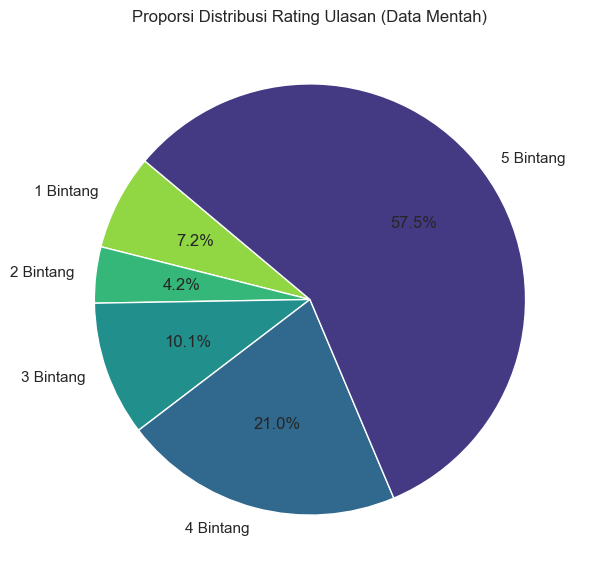

Membuat Word Cloud...


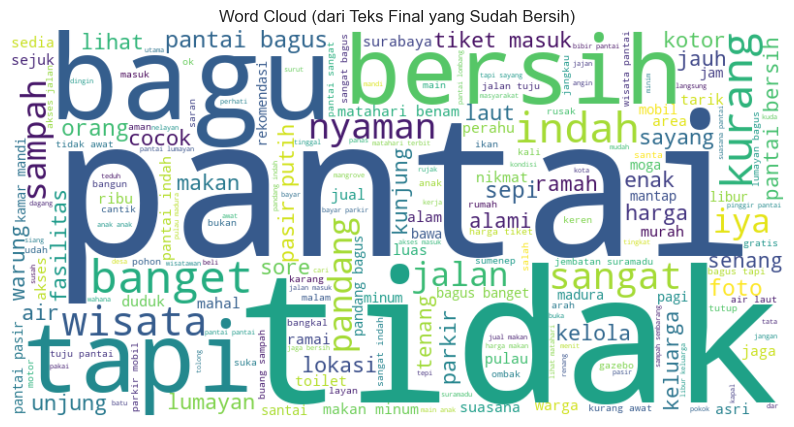

Membuat Bar Chart Top 20 Bigrams (Frasa 2-Kata)...


C:\Users\Administrator\AppData\Local\Temp\ipykernel_8408\375596328.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_bigrams.values, y=top_20_bigrams.index, palette='plasma')


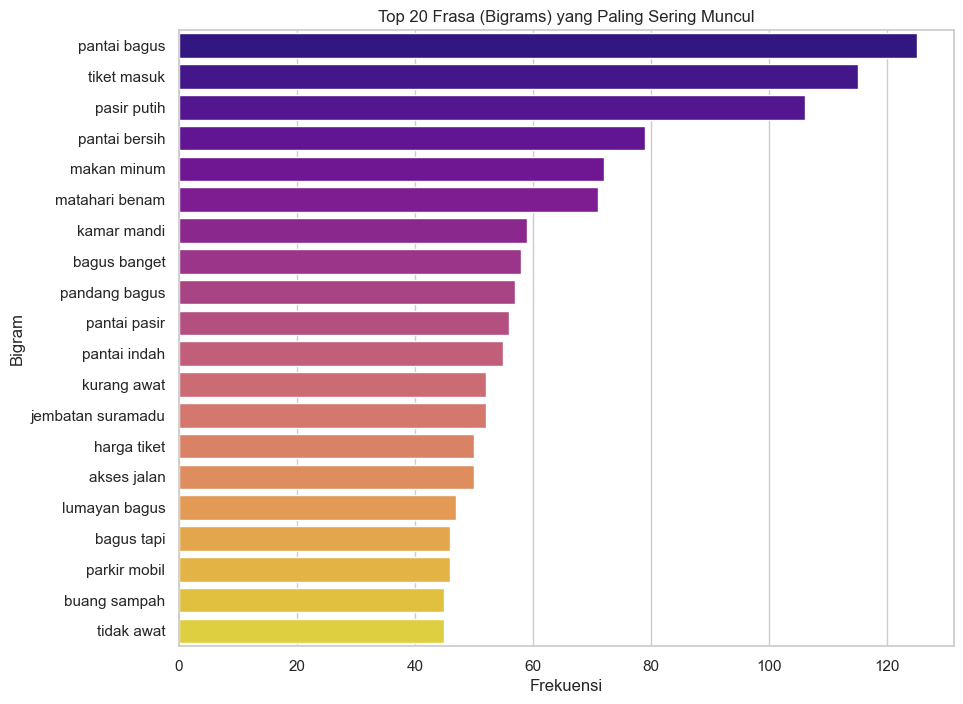


--- EDA (BATAS LAPORAN ANDA) SELESAI ---


In [12]:
#################################################################
# SEL 6: EXPLORATORY DATA ANALYSIS (EDA)
# (Output untuk Laporan Anda)
#################################################################
print("\n--- TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ---")
sns.set(style="whitegrid")

# 1. Visualisasi Distribusi Rating (Insight data mentah)
print("\nMembuat Pie Chart Distribusi Rating...")
rating_counts = df_processed['rating'].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(
    rating_counts,
    labels=rating_counts.index.map(lambda r: f'{r} Bintang'),
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis_r', n_colors=5)
)
plt.title('Proporsi Distribusi Rating Ulasan (Data Mentah)')
plt.show()

# 2. Visualisasi Word Cloud (dari teks paling bersih)
print("Membuat Word Cloud...")
all_text = ' '.join(df_processed['final_cleaned_text'])

if all_text:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud (dari Teks Final yang Sudah Bersih)')
    plt.show()
else:
    print("Tidak ada teks untuk dibuat Word Cloud.")

# 3. Visualisasi Bar Chart Top N-Grams (Bigrams)
print("Membuat Bar Chart Top 20 Bigrams (Frasa 2-Kata)...")
vec_bigrams = CountVectorizer(ngram_range=(2, 2), min_df=5)
bigram_matrix = vec_bigrams.fit_transform(df_processed['final_cleaned_text'])
bigram_counts = pd.DataFrame(
    bigram_matrix.toarray(),
    columns=vec_bigrams.get_feature_names_out()
).sum().sort_values(ascending=False)
top_20_bigrams = bigram_counts.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_bigrams.values, y=top_20_bigrams.index, palette='plasma')
plt.title('Top 20 Frasa (Bigrams) yang Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')
plt.show()

print("\n--- EDA (BATAS LAPORAN ANDA) SELESAI ---")

In [13]:
#################################################################
# SEL 7: PELABELAN SENTIMEN (LEXICON-BASED MANUAL)
# PERBAIKAN BESAR: Membuat Target (y) kita sendiri
# Ini MENGGANTIKAN penggunaan 'rating' sebagai target.
#################################################################
print("\n--- Memulai Pelabelan Sentimen (Lexicon-Based Manual) ---")

# 1. Buat Kamus Sentimen (Lexicon) Manual
# (Ini bisa kamu tambahkan dari repo onpilot/sentimen-bahasa atau EDA)
lexicon_positif = {
    'bagus', 'indah', 'bersih', 'nyaman', 'tenang', 'ramah', 'keren',
    'murah', 'terjangkau', 'puas', 'menyenangkan', 'cocok', 'rekomendasi',
    'unik', 'syahdu', 'sejuk', 'adem', 'alami', 'asri', 'terawat',
    'luas', 'gratis', 'mantap', 'jernih', 'sepi', 'puas'
}

lexicon_negatif = {
    'kotor', 'sampah', 'mahal', 'panas', 'jauh', 'susah', 'rusak',
    'kurang', 'tidak', 'bukan', 'jelek', 'kecewa', 'sulit', 'bau',
    'kumuh', 'berisik', 'ramai', 'terbengkalai', 'curam', 'sempit',
    'macet', 'pungli', 'mahal', 'mengecewakan', 'kotor'
}
print(f"Kamus sentimen manual dibuat ({len(lexicon_positif)} Pos, {len(lexicon_negatif)} Neg).")

# 2. Buat Fungsi Pelabelan
def get_sentiment_label_manual(text):
    tokens = text.split()
    score = 0
    negation_words = {'tidak', 'bukan', 'jangan'}
    negate = False

    for word in tokens:
        if word in lexicon_positif:
            score += -1 if negate else 1
            negate = False # Reset negasi
        elif word in lexicon_negatif:
            score += 1 if negate else -1
            negate = False # Reset negasi
        elif word in negation_words:
            negate = True # Aktifkan negasi untuk kata berikutnya
        else:
            negate = False # Reset jika kata netral

    # Tentukan label
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

# 3. Terapkan pelabelan ke DataFrame
print("Menerapkan pelabelan sentimen ke semua data...")
# PENTING: Terapkan pada 'final_cleaned_text'
df_processed['sentiment_label'] = df_processed['final_cleaned_text'].apply(get_sentiment_label_manual)

print("--- Pelabelan Sentimen Manual Selesai ---")
print("Distribusi Label Sentimen (Target y) Baru Anda:")
print(df_processed['sentiment_label'].value_counts())

# Tampilkan perbandingan antara rating asli dan label baru
print("\nContoh Perbandingan Rating Asli vs Label Baru:")
pd.set_option('display.max_colwidth', 50) # Agar teks tidak terlalu panjang
print(df_processed[['review_text', 'rating', 'final_cleaned_text', 'sentiment_label']].head())


--- Memulai Pelabelan Sentimen (Lexicon-Based Manual) ---
Kamus sentimen manual dibuat (25 Pos, 23 Neg).
Menerapkan pelabelan sentimen ke semua data...
--- Pelabelan Sentimen Manual Selesai ---
Distribusi Label Sentimen (Target y) Baru Anda:
sentiment_label
Positif    1229
Netral      966
Negatif     607
Name: count, dtype: int64

Contoh Perbandingan Rating Asli vs Label Baru:
                                         review_text  rating  \
0             Sperti apa ya sekarang akses masuknya?       5   
3                   Pantai yg indah dengan sunsetnya       5   
4  Tempat  bagus untuk cari ikan baik ngobor atau...       5   
5                                       Kahona beach       5   
6  Untuk Akses Nyampek Kepantainya Bisa Di Lewati...       1   

                                  final_cleaned_text sentiment_label  
0                                    iya akses masuk          Netral  
3                             pantai indah sunsetnya         Positif  
4  bagus cari ikan ng

In [14]:
#################################################################
# SEL 8: EKSTRAKSI FITUR (TF-IDF)
# Menyiapkan data final untuk Machine Learning
#################################################################
print("\n--- Memulai Ekstraksi Fitur (TF-IDF) ---")

# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2)) # Pakai uni+bigram

# PERBAIKAN: Menentukan X dan y yang TEPAT
X_text = df_processed['final_cleaned_text']     # <-- Ini adalah X
y_labels = df_processed['sentiment_label']    # <-- Ini adalah y (dari lexicon manual)

# Terapkan TF-IDF
print("Menerapkan TF-IDF pada kolom 'final_cleaned_text'...")
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print(f"Bentuk Matriks TF-IDF (X_tfidf): {X_tfidf.shape}")
print(f"Bentuk Target (y_labels): {y_labels.shape}")

print("\n--- Proses Ekstraksi Fitur Selesai ---")
print("Variabel 'X_tfidf' (fitur X) dan 'y_labels' (target y) siap untuk pemodelan.")


--- Memulai Ekstraksi Fitur (TF-IDF) ---
Menerapkan TF-IDF pada kolom 'final_cleaned_text'...
Bentuk Matriks TF-IDF (X_tfidf): (2802, 5000)
Bentuk Target (y_labels): (2802,)

--- Proses Ekstraksi Fitur Selesai ---
Variabel 'X_tfidf' (fitur X) dan 'y_labels' (target y) siap untuk pemodelan.


In [ ]:
#################################################################
# SEL 9: PEMODELAN (KLASIFIKASI SUPERVISED)
# Sesuai Laporan Anda: Logistic Regression, Naive Bayes, SVM
#################################################################
print("\n--- TAHAP PEMODELAN (KLASIFIKASI) ---")

# 1. Split Data (Train & Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_labels,
    test_size=0.2,       # 20% data untuk testing
    random_state=42,     # Agar hasil konsisten
    stratify=y_labels    # Menjaga proporsi Pos/Neg/Net
)
print(f"Data dibagi menjadi {X_train.shape[0]} train dan {X_test.shape[0]} test.")

# 2. Model 1: Logistic Regression
print("\Training Model 1: Logistic Regression...")
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("--- Result for Logistic Regression ---")
print(classification_report(y_test, y_pred_lr))

# 3. Model 2: Multinomial Naive Bayes
print("\Training Model 2: Multinomial Naive Bayes...")
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
print("--- Result for Multinomial Naive Bayes ---")
print(classification_report(y_test, y_pred_nb))

# 4. Model 3: Support Vector Machine (SVM)
print("\Training Model 3: Support Vector Machine (SVM)...")
model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
print("--- Result for Support Vector Machine (SVM) ---")
print(classification_report(y_test, y_pred_svm))

print("\n--- PROSES PROYEK LENGKAP SELESAI ---")


--- TAHAP PEMODELAN (KLASIFIKASI) ---
Data dibagi menjadi 2241 train dan 561 test.

Melatih Model 1: Logistic Regression...
--- Hasil Logistic Regression ---
              precision    recall  f1-score   support

     Negatif       0.92      0.71      0.80       122
      Netral       0.75      0.82      0.78       193
     Positif       0.89      0.91      0.90       246

    accuracy                           0.84       561
   macro avg       0.85      0.82      0.83       561
weighted avg       0.84      0.84      0.84       561


Melatih Model 2: Multinomial Naive Bayes...
--- Hasil Multinomial Naive Bayes ---
              precision    recall  f1-score   support

     Negatif       0.90      0.45      0.60       122
      Netral       0.63      0.36      0.46       193
     Positif       0.61      0.96      0.74       246

    accuracy                           0.64       561
   macro avg       0.71      0.59      0.60       561
weighted avg       0.68      0.64      0.61       5

In [16]:
# DEFINISI ASPEK DAN LEXICON KHUSUS UNTUK ABSA

print("--- Mempersiapkan Aspek dan Lexicon Khusus untuk ABSA ---")

# Aspek yang akan dianalisis (dipindahkan dari sel 54970ff6)
aspect_list = [
    'keamanan', 'kebersihan', 'keindahan','fasilitas', 'aksesibilit'
]

# Kamus sentimen positif khusus untuk ABSA (disalin dari lexicon umum)
lexicon_positif_absa = {
    'bagus', 'indah', 'bersih', 'nyaman', 'tenang', 'ramah', 'keren',
    'murah', 'terjangkau', 'puas', 'menyenangkan', 'cocok', 'rekomendasi',
    'unik', 'syahdu', 'sejuk', 'adem', 'alami', 'asri', 'terawat',
    'luas', 'gratis', 'mantap', 'jernih', 'sepi', 'puas'
}

# Kamus sentimen negatif khusus untuk ABSA (disalin dari lexicon umum)
lexicon_negatif_absa = {
    'kotor', 'sampah', 'mahal', 'panas', 'jauh', 'susah', 'rusak',
    'kurang', 'tidak', 'bukan', 'jelek', 'kecewa', 'sulit', 'bau',
    'kumuh', 'berisik', 'ramai', 'terbengkalai', 'curam', 'sempit',
    'macet', 'pungli', 'mahal', 'mengecewakan', 'kotor'
}

print(f"Daftar aspek: {aspect_list}")
print(f"Lexicon positif ABSA dibuat ({len(lexicon_positif_absa)} kata).")
print(f"Lexicon negatif ABSA dibuat ({len(lexicon_negatif_absa)} kata).")
print("--- Persiapan ABSA Selesai ---")


--- Mempersiapkan Aspek dan Lexicon Khusus untuk ABSA ---
Daftar aspek: ['keamanan', 'kebersihan', 'keindahan', 'fasilitas', 'aksesibilit']
Lexicon positif ABSA dibuat (25 kata).
Lexicon negatif ABSA dibuat (23 kata).
--- Persiapan ABSA Selesai ---


In [17]:
#################################################################
# SEL 10: ANALISIS SENTIMEN BERBASIS ASPEK
# Mengidentifikasi sentimen untuk setiap aspek yang didefinisikan
#################################################################
print("\n--- Memulai Analisis Sentimen Berbasis Aspek ---")

# Memastikan aspek_list, lexicon_positif_absa, dan lexicon_negatif_absa sudah ada dari sel sebelumnya

def get_aspect_sentiment(text, aspect_list, lexicon_positif, lexicon_negatif, window_size=3):
    tokens = text.split()
    aspect_sentiments = {}

    for aspect in aspect_list:
        # Mencari keberadaan aspek dalam teks
        # Kita harus mempertimbangkan stemming untuk aspek jika diperlukan
        # Untuk saat ini, kita anggap aspek_list sudah sesuai dengan token setelah stemming

        aspect_found = False
        aspect_score = 0
        negate = False

        # Coba stem aspek juga untuk pencarian yang lebih akurat
        stemmed_aspect = stemmer.stem(aspect)

        for i, token in enumerate(tokens):
            if stemmed_aspect == token or aspect == token: # Cek aspek asli atau yang distemmed
                aspect_found = True

                # Ambil konteks sekitar aspek
                start_idx = max(0, i - window_size)
                end_idx = min(len(tokens), i + window_size + 1)
                context_tokens = tokens[start_idx:i] + tokens[i+1:end_idx]

                # Hitung sentimen dalam konteks
                for word in context_tokens:
                    if word in lexicon_positif:
                        aspect_score += -1 if negate else 1
                        negate = False
                    elif word in lexicon_negatif:
                        aspect_score += 1 if negate else -1
                        negate = False
                    elif word in {'tidak', 'bukan', 'jangan'}: # Kata negasi
                        negate = True
                    else:
                        negate = False
                break # Asumsi kita hanya perlu sentimen pertama kali aspek muncul

        if aspect_found:
            if aspect_score > 0:
                aspect_sentiments[aspect] = 'Positif'
            elif aspect_score < 0:
                aspect_sentiments[aspect] = 'Negatif'
            else:
                aspect_sentiments[aspect] = 'Netral'
        else:
            aspect_sentiments[aspect] = 'Tidak Disebutkan'

    return aspect_sentiments

# Terapkan fungsi ke dataframe
print("Menerapkan analisis sentimen berbasis aspek...")
df_processed['aspect_sentiments'] = df_processed['final_cleaned_text'].apply(
    lambda x: get_aspect_sentiment(x, aspect_list, lexicon_positif_absa, lexicon_negatif_absa)
)

print("--- Analisis Sentimen Berbasis Aspek Selesai ---")
print("Contoh hasil analisis sentimen berbasis aspek:")
display(df_processed[['review_text', 'final_cleaned_text', 'aspect_sentiments']].head())

# Opsional: Analisis distribusi sentimen untuk setiap aspek
print("\nDistribusi Sentimen untuk Setiap Aspek:")
aspect_sentiment_counts = {aspect: Counter() for aspect in aspect_list}

for index, row in df_processed.iterrows():
    for aspect, sentiment in row['aspect_sentiments'].items():
        if aspect in aspect_sentiment_counts:
            aspect_sentiment_counts[aspect][sentiment] += 1

for aspect, counts in aspect_sentiment_counts.items():
    print(f"\nAspek: {aspect}")
    for sentiment, count in counts.most_common():
        print(f"  {sentiment}: {count}")



--- Memulai Analisis Sentimen Berbasis Aspek ---
Menerapkan analisis sentimen berbasis aspek...
--- Analisis Sentimen Berbasis Aspek Selesai ---
Contoh hasil analisis sentimen berbasis aspek:


,review_text,final_cleaned_text,aspect_sentiments
0,Sperti apa ya sekarang akses masuknya?,iya akses masuk,"{'keamanan': 'Tidak Disebutkan', 'kebersihan':..."
3,Pantai yg indah dengan sunsetnya,pantai indah sunsetnya,"{'keamanan': 'Tidak Disebutkan', 'kebersihan':..."
4,Tempat bagus untuk cari ikan baik ngobor atau...,bagus cari ikan ngobor ngejaring kampung ku ka...,"{'keamanan': 'Tidak Disebutkan', 'kebersihan':..."
5,Kahona beach,kahona pantai,"{'keamanan': 'Tidak Disebutkan', 'kebersihan':..."
6,Untuk Akses Nyampek Kepantainya Bisa Di Lewati...,akses pantai lewatin mobil tidak kakak,"{'keamanan': 'Tidak Disebutkan', 'kebersihan':..."



Distribusi Sentimen untuk Setiap Aspek:

Aspek: keamanan
  Tidak Disebutkan: 2757
  Netral: 19
  Positif: 19
  Negatif: 7

Aspek: kebersihan
  Tidak Disebutkan: 2453
  Netral: 146
  Positif: 126
  Negatif: 77

Aspek: keindahan
  Tidak Disebutkan: 2494
  Netral: 171
  Positif: 106
  Negatif: 31

Aspek: fasilitas
  Tidak Disebutkan: 2700
  Netral: 36
  Negatif: 34
  Positif: 32

Aspek: aksesibilit
  Tidak Disebutkan: 2802
